<h1>NetworkX

In [1]:
import networkx as nx

In [91]:
G = nx.Graph() # 네트워크 생성
G.add_node(1) # node 추가
G.add_node(2)
G.add_edge(1,2) # 1번 2번 노드 연결

In [92]:
G.add_nodes_from([3,4,5])
G.add_edges_from([(3,4),(3,5)])

In [93]:
G.nodes() # 현재 노드

NodeView((1, 2, 3, 4, 5))

In [94]:
G.edges() # 현재 링크

EdgeView([(1, 2), (3, 4), (3, 5)])

In [14]:
D = nx.DiGraph() # 방향 네트워크 생성

In [16]:
D.add_edge(1,2) # 1 -> 2
D.add_edge(2,1) # 2 -> 1 양방향

In [17]:
D.number_of_nodes() # 노드 수 반환

2

In [19]:
D.number_of_edges() # 엣지 수 반환

2

In [22]:
D.predecessors(1) # 들어오는 노드 확인

In [21]:
D.successors(2) # 나가는 노드 확인

In [28]:
print(list(D.predecessors(1)))
print(list(D.predecessors(2)))

[2]
[1]


In [29]:
print(list(D.successors(1)))
print(list(D.successors(2)))

[2]
[1]


In [30]:
# 나머지 그래프들 생성

B = nx.complete_bipartite_graph(4,5) # 이분 네트워크
C = nx.cycle_graph(4) # 사이클 네트워크
P = nx.path_graph(3) # 경로 네트워크
S = nx.star_graph(6) # 성형 네트워크

In [31]:
# Density 관련 모듈

nx.density(G)
nx.density(D)

CG = nx.complete_graph(8471) # 큰 그래프 생성 density 가 1인 그래프를 생성

print(nx.density(CG))

1.0


In [36]:
K4 = nx.complete_graph(5)

subG = nx.subgraph(K4, (1,2,3))
print("NODES : " + str(nx.nodes(subG)))
print("EDGES : " + str(nx.edges(subG))) # Clique

NODES : [1, 2, 3]
EDGES : [(1, 2), (1, 3), (2, 3)]


In [38]:
print(nx.nodes(G)) # G 네트워크 구성 확인
print(nx.edges(G))

[1, 2, 3, 4, 5]
[(1, 2), (3, 4), (3, 5)]


In [45]:
print(G.degree(2))
G.degree() # 각 노드의 연결선 수 딕셔너리 타입으로 반환

1


DegreeView({1: 1, 2: 1, 3: 2, 4: 1, 5: 1})

In [50]:
print(nx.number_of_nodes(G)) # 방향 네트워크 구성 확인
print(nx.number_of_edges(G))

5
3


In [54]:
print(D.in_degree()) # 들어오는 차수
print(D.out_degree()) # 나가는 차수
print(D.degree()) # in degree + out degree

[(1, 1), (2, 1)]
[(1, 1), (2, 1)]
[(1, 2), (2, 2)]


In [55]:
# 가중치 네트워크

W = nx.Graph()
W.add_edge(1,2, weight=6) # weight 매개변수 추가
W.add_weighted_edges_from([(2,3,3),(2,4,5)])

In [57]:
# 연결 강도 확인
W.degree(2, weight= 'weight')

14

In [64]:
# adjacency matrix

matrix = nx.to_numpy_array(G)

print(matrix)


[[0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]]


False


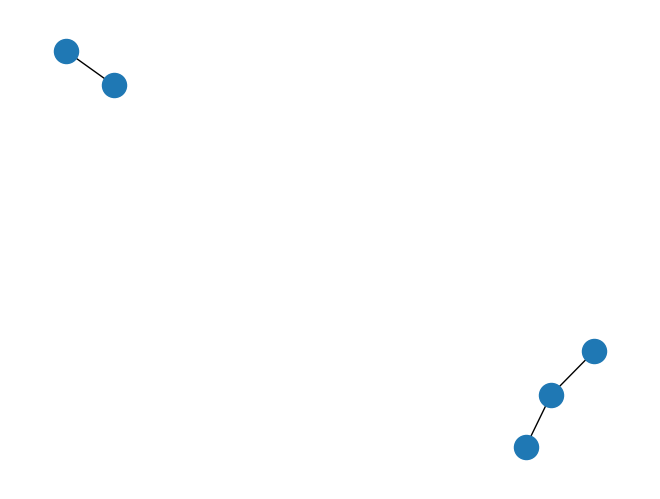

In [97]:
nx.draw(G)
print(nx.is_connected(G)) # 현재 연결 되어있는지 확인

In [98]:
G.add_edge(2,3)

True


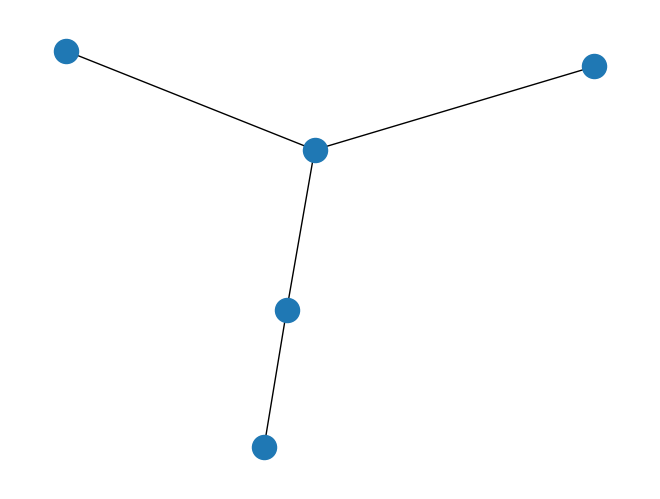

In [101]:
nx.draw(G)
print(nx.is_connected(G))

In [81]:
print(nx.degree_assortativity_coefficient(G))

-0.6666666666666666


In [90]:
# 경로 혹은 거리 관련 모듈

print(nx.has_path(G,1,2)) # 경로 존재 여부
print(nx.shortest_path_length(G,1,3)) # 최단 경로 길이
nx.shortest_path(G,1,3) # 최단 경로

True
2


[1, 2, 3]

In [111]:
print(nx.triangles(G)) # 삼각 구조 개수
print(nx.average_clustering(G)) #네트워크의 clustering coefficient

{1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
0.0


In [115]:
# 근접 중심도 계산 모듈

print(nx.closeness_centrality(G,3))
print(round(nx.closeness_centrality(G,1),1))

0.8
0.4


In [119]:
# 사이 중심도 계산 모듈
print(nx.betweenness_centrality(G)) # 노드 중심
print(nx.edge_betweenness_centrality(G)) # 링크 중심

{1: 0.0, 2: 0.5, 3: 0.8333333333333333, 4: 0.0, 5: 0.0}
{(1, 2): 0.4, (2, 3): 0.6000000000000001, (3, 4): 0.4, (3, 5): 0.4}


In [130]:
# 코어 관련

print(nx.core_number(G)) # 가장 높은 연결 차수 반환

print(nx.k_core(G,2)) # 특정 값 이상을 가진 노드들로 구성된 서브그래프 반환
print(nx.k_core(G,1))

print(nx.k_shell(G,1)) # core number가 k인 노드들로만 추출


{1: 1, 2: 1, 3: 1, 4: 1, 5: 1}
Graph with 0 nodes and 0 edges
Graph with 5 nodes and 4 edges
Graph with 5 nodes and 4 edges


In [132]:
# 페이지 랭크 계산

PR_dict =nx.pagerank(G)
print(PR_dict)

{1: 0.1343338512203446, 2: 0.24549256100607264, 3: 0.357556987250496, 4: 0.13130830026154344, 5: 0.13130830026154344}


In [141]:
# 네트워크 모델 관련

# G = nx.gnm_random_graph(4,5) # 랜덤 네트워크 모델
# G = nx.gnp_random_graph(4,5) # 길버트 모델
# G = nx.watts_strogatz_graph(5,4,0.01) # 좁은 세상 모델
# G = nx.configuration_model(D) # 구조 모델

G = nx.barabasi_albert_graph(5,4) # BA 모델 네트워크

In [142]:
# 커니건-린

partition = nx.community.kernighan_lin_bisection(G)

In [143]:
# 거번-뉴먼

partitions = nx.community.girvan_newman(G)